# Do augmentations help?

Four runs on the new cube dataset, differing only in which augmentations are enabled:

| label | run | `augment_fft` | `augment_mask` |
|---|---|---|---|
| no aug | `new-cubes-4` | ✗ | ✗ |
| fft | `1785152705-platinum-herring` | ✓ | ✗ |
| mask | `1785055032-amber-lemur` | ✗ | ✓ |
| fft + mask | `1785058508-amber-dormouse` | ✓ | ✓ |

The runs trained for different numbers of epochs (6000 / 2000 / 3500 / 5499). The shortest
is 2000 epochs, so **every comparison below is made at epoch 2000** — that is the only
point where all four runs have data, and comparing a 6000-epoch checkpoint against a
2000-epoch one would confound the augmentation effect with training length.

Metric is `soft-iou`, on the **no-speaker** layouts only (`*_speaker` eval sets are ignored):
`train`, `green_cube`, `purple_cube`, `purple_green_cubes`.

In [1]:
import re
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

RUNS_DIR = Path('/home/ethantu/workspace/good-vibrations/runs')

# label -> run directory. Order here is the order used in the plot legend.
RUNS = {
    'no aug':     'new-cubes-4',
    'fft':        '1785152705-platinum-herring',
    'mask':       '1785055032-amber-lemur',
    'fft + mask': '1785058508-amber-dormouse',
}

TARGET_EPOCH = 2000  # shortest run, so this is the deepest point all four runs share

# metric key -> display name for the x axis. Speaker variants are deliberately excluded.
LAYOUTS = {
    'metrics/train/soft-iou':                    'train',
    'metrics/eval/green_cube/soft-iou':          'green cube',
    'metrics/eval/purple_cube/soft-iou':         'purple cube',
    'metrics/eval/purple_green_cubes/soft-iou':  'green+purple cube',
}

## 1. Parse the run logs

Metrics live in `runs/<run>/logs-rank0.txt`, written by the composer `FileLogger`, one line per
scalar:

```
[metric][batch=12000]: metrics/eval/green_cube/soft-iou: 0.6493
```

Everything is indexed by **batch**, not epoch, and the runs have different batches-per-epoch
(`new-cubes-4` logs 6 batches/epoch, the others 3), so batch numbers are not comparable across
runs. The logs also emit `time/epoch` at each batch boundary, which gives an exact batch → epoch
map per run; we use that to align the runs rather than assuming a fixed ratio.

In [2]:
METRIC_RE = re.compile(r'\[metric\]\[batch=(\d+)\]: ([\w/+-]+): ([-\d.eE+]+)\s*$')


def parse_log(run_dir):
    """Return a long dataframe of soft-iou values with columns [batch, epoch, key, value].

    Rows whose batch has no `time/epoch` entry are dropped (the very first eval, at batch 0,
    fires before any epoch boundary is logged).
    """
    batch2epoch, rows = {}, []
    for line in (RUNS_DIR / run_dir / 'logs-rank0.txt').read_text(errors='ignore').splitlines():
        m = METRIC_RE.search(line)
        if not m:
            continue
        batch, key, value = int(m.group(1)), m.group(2), float(m.group(3))
        if key == 'time/epoch':
            batch2epoch[batch] = int(value)
        elif key.endswith('/soft-iou'):
            rows.append((batch, key, value))
    df = pd.DataFrame(rows, columns=['batch', 'key', 'value'])
    df['epoch'] = df['batch'].map(batch2epoch)
    return df.dropna(subset=['epoch']).astype({'epoch': int})


logs = {label: parse_log(d) for label, d in RUNS.items()}

for label, df in logs.items():
    print(f'{label:>11s}  {RUNS[label]:<28s} max epoch={df.epoch.max():5d}  n_points={len(df)}')

     no aug  new-cubes-4                  max epoch= 6000  n_points=12734
        fft  1785152705-platinum-herring  max epoch= 2000  n_points=4254
       mask  1785055032-amber-lemur       max epoch= 3500  n_points=7427
 fft + mask  1785058508-amber-dormouse    max epoch= 5499  n_points=11660


## 2. Snapshot every run at epoch 2000

All four runs happen to have an eval logged at exactly epoch 2000, so no interpolation or
nearest-neighbour fudging is needed. The assertion below fails loudly if that ever stops being
true, rather than silently comparing different epochs.

One wrinkle: `train` soft-IoU is logged twice per epoch — once *during* training (with
augmentations and dropout live) and once by the clean train-eval pass afterwards. Only the clean
pass is comparable to the eval layouts, so the later of the two is used.

In [3]:
records = []
for label, df in logs.items():
    at = df[df.epoch == TARGET_EPOCH]
    for key, layout in LAYOUTS.items():
        vals = at[at.key == key].value.values
        # `metrics/train/soft-iou` is logged twice per epoch: once during training (augmentations
        # and dropout active) and again by the clean train-eval pass that runs after it. The eval
        # layouts only have the clean pass, so take the last value to compare like with like.
        assert len(vals) in (1, 2), f'{label}: unexpected {len(vals)} values for {key} at epoch {TARGET_EPOCH}'
        records.append(dict(run=label, layout=layout, soft_iou=vals[-1]))

scores = (pd.DataFrame(records)
            .pivot(index='layout', columns='run', values='soft_iou')
            .reindex(index=list(LAYOUTS.values()), columns=list(RUNS)))
scores

run,no aug,fft,mask,fft + mask
layout,,,,
train,0.8942,0.8987,0.8353,0.8386
green cube,0.6493,0.6294,0.6319,0.6240
purple cube,0.5795,0.6072,0.5685,0.5615
green+purple cube,0.3873,0.3933,0.3858,0.4072


## 3. Bar plot

One group per layout, four bars per group (one per run), so the augmentation variants sit
side by side within each layout.

These are the **logged** values, which carry no spread: `SoftIoU` accumulates a running
`total`/`count` and logs only the ratio, so std cannot be recovered from the logs. The error bars
are therefore added later, in **section 7**, from the per-sample IoU vectors that the section-6
checkpoint re-run produces. This plot is the means-only view; section 7 is the same comparison
with ±1 std.

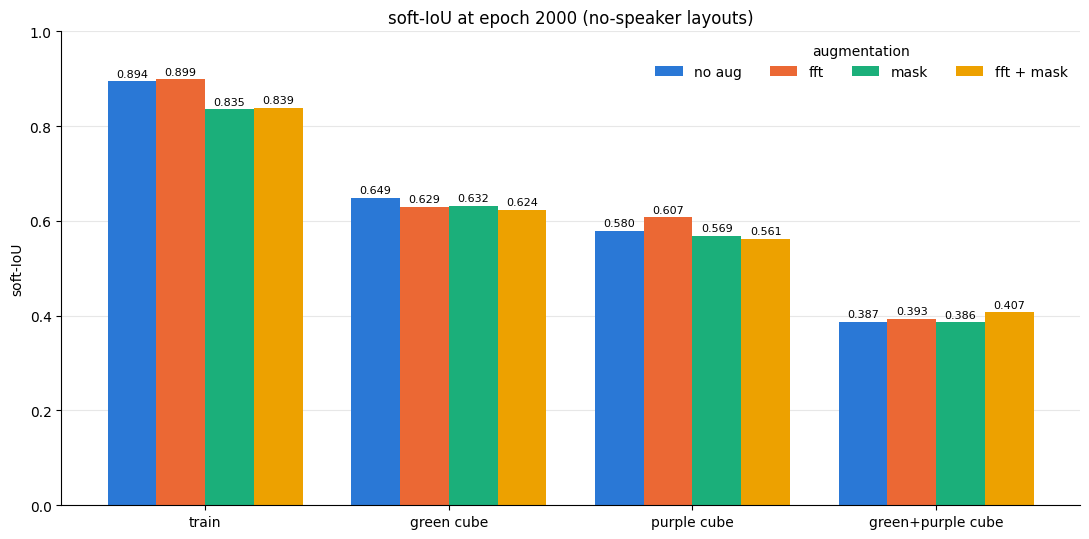

In [4]:
# Categorical hues in fixed slot order from a validated palette (light-mode steps).
# Checked with the palette validator: lightness band / chroma floor / CVD separation
# (worst adjacent ΔE 9.1) / normal-vision floor (22.9) all pass on the adjacent pairlist.
# Two hues sit under 3:1 vs the surface, so every bar carries a visible value label.
COLORS = {'no aug': '#2a78d6', 'fft': '#eb6834', 'mask': '#1baf7a', 'fft + mask': '#eda100'}

layouts = list(scores.index)
runs = list(scores.columns)
x = np.arange(len(layouts))
width = 0.8 / len(runs)

fig, ax = plt.subplots(figsize=(11, 5.5))
for i, run in enumerate(runs):
    offset = (i - (len(runs) - 1) / 2) * width
    bars = ax.bar(x + offset, scores[run].values, width, label=run, color=COLORS[run])
    ax.bar_label(bars, fmt='%.3f', fontsize=8, padding=2)

ax.set_xticks(x, layouts)
ax.set_ylabel('soft-IoU')
ax.set_ylim(0, 1.0)
ax.set_title(f'soft-IoU at epoch {TARGET_EPOCH} (no-speaker layouts)')
ax.legend(title='augmentation', ncols=len(runs), loc='upper right', frameon=False)
ax.grid(axis='y', alpha=0.3)
ax.set_axisbelow(True)
for spine in ('top', 'right'):
    ax.spines[spine].set_visible(False)

plt.tight_layout()
plt.show()

## 4. Deltas vs. no augmentation

Same numbers, expressed as change relative to the `no aug` baseline, which is what the
question actually asks about.

In [5]:
deltas = scores.drop(columns='no aug').sub(scores['no aug'], axis=0)
deltas.style.format('{:+.4f}').background_gradient(cmap='RdYlGn', vmin=-0.06, vmax=0.06)

run,fft,mask,fft + mask
layout,,,
train,+0.0045,-0.0589,-0.0556
green cube,-0.0199,-0.0174,-0.0253
purple cube,+0.0277,-0.0110,-0.0180
green+purple cube,+0.0060,-0.0015,+0.0199


## 5. Training curves for context

A single epoch is a noisy snapshot. These curves show the full trajectory of each eval layout,
with the epoch-2000 comparison point marked, so it is visible whether the epoch-2000 gaps are
a stable separation or just eval noise.

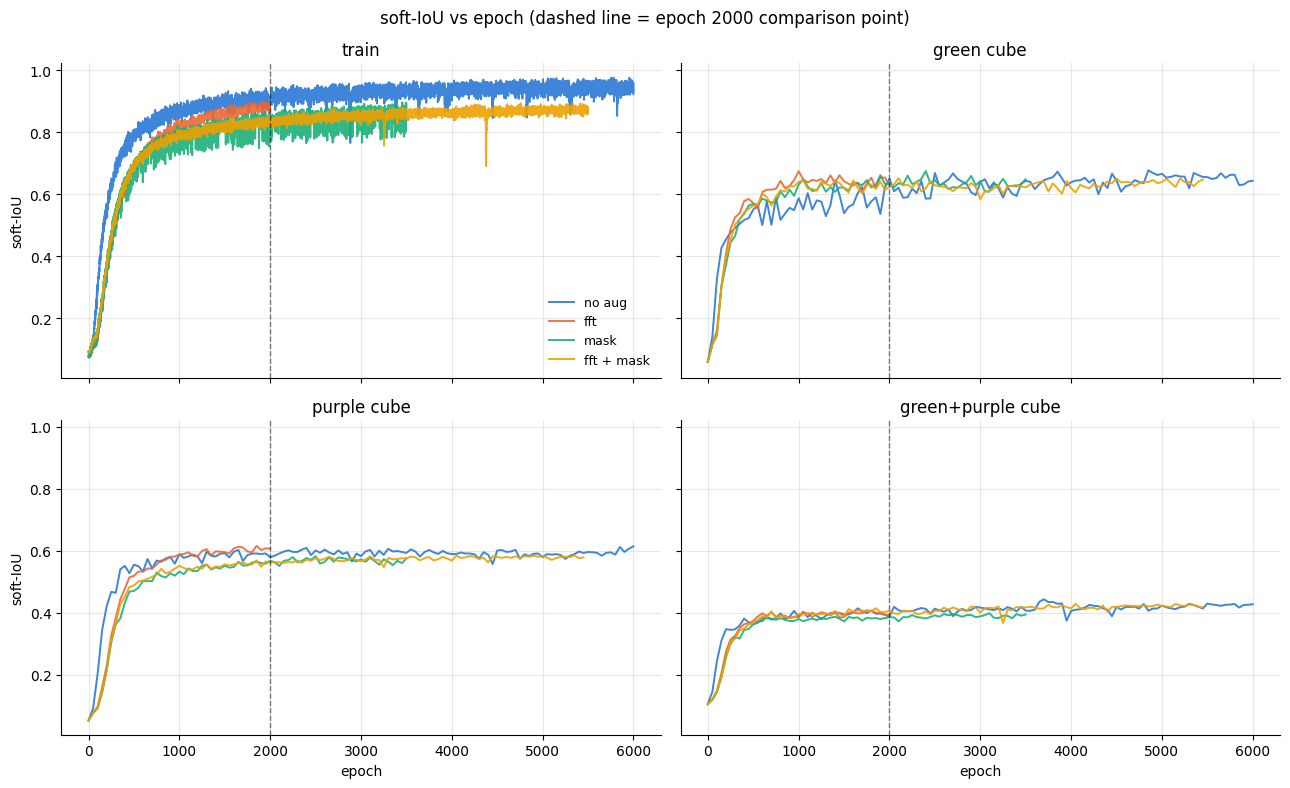

In [6]:
fig, axes = plt.subplots(2, 2, figsize=(13, 8), sharex=True, sharey=True)

for ax, (key, layout) in zip(axes.flat, LAYOUTS.items()):
    for run in runs:
        s = logs[run]
        s = s[s.key == key].sort_values('epoch')
        # keep the clean train-eval pass where a metric is logged twice per epoch (see section 2)
        s = s.groupby('epoch', as_index=False).last()
        ax.plot(s.epoch, s.value, label=run, color=COLORS[run], lw=1.4, alpha=0.9)
    ax.axvline(TARGET_EPOCH, color='k', ls='--', lw=1, alpha=0.5)
    ax.set_title(layout)
    ax.grid(alpha=0.3)
    ax.set_axisbelow(True)
    for spine in ('top', 'right'):
        ax.spines[spine].set_visible(False)

for ax in axes[-1]:
    ax.set_xlabel('epoch')
for ax in axes[:, 0]:
    ax.set_ylabel('soft-IoU')
axes[0, 0].legend(frameon=False, fontsize=9)

fig.suptitle(f'soft-IoU vs epoch (dashed line = epoch {TARGET_EPOCH} comparison point)')
plt.tight_layout()
plt.show()

## 6. Center-of-mass error, split into x and y

The question here is per-axis COM error, but **the logs cannot answer it**. `CenterOfMassDistance`
reduces the `(row, col)` offset to a single L2 norm before logging:

```python
com_dist = center_of_mass(mask_pred, ...) - center_of_mass(mask_true, ...)
return torch.linalg.norm(com_dist, ord=2, dim=-1)
```

so only `metrics/*/com-distance` is stored, and the x and y components are irrecoverable from it
(the checkpoints' `eval_metrics` hold the same reduced scalar). Recovering them requires re-running
inference, which is what the next cell does, loading each run's **`ep2000` checkpoint** so the
comparison point matches the rest of the notebook.

Two details this has to get right:

- **Different MDS builds.** `build_dataset` hashes `raw_fft = augment_fft > 0` into the MDS
  directory name, so the `fft` runs read a *different* (raw-complex-FFT) build than the others.
  The mapping is hardcoded below.
- **Augmentations off.** Eval always uses `augment_fft=0, augment_mask=0`; the augmentations are
  a training-time-only difference.

Per request this covers **single-object layouts only** (`green_cube`, `purple_cube`) — the
`purple_green_cubes` layout is excluded, as are the `*_speaker` sets.

COM is returned as `(row, col)`, so **y = row** (vertical) and **x = col** (horizontal). Both are
normalized to `[0, 1]` by `(H-1, W-1)`, so x and y errors are in comparable units.

In [7]:
import sys
from torch.utils.data import DataLoader, Subset
import torch

sys.path.insert(0, '/home/ethantu/workspace/good-vibrations')
sys.path.insert(0, '/home/ethantu/workspace/good-vibrations/src')

from model.arch import VibrationTransformer
from model.dataset import VibrationDataset, exp25_split
from utils.metrics import center_of_mass, soft_iou

ROOT = Path('/home/ethantu/workspace/good-vibrations')

# MDS build is selected by a content hash that includes raw_fft (== augment_fft > 0),
# so the fft runs read a different build than the rest.
MDS_RAW_FFT = ROOT / 'experiments/experiment-25/mds/4d1cae61842093b7'
MDS_PRECOMP = ROOT / 'experiments/experiment-25/mds/19b982fa1e001563'

CKPTS = {
    'no aug':     dict(dir='new-cubes-4',                 ckpt='ep2000-ba12000-rank0.pt', mds=ROOT / 'datasets/016/mds', raw_fft=False),
    'fft':        dict(dir='1785152705-platinum-herring', ckpt='ep2000-ba6000-rank0.pt',  mds=MDS_RAW_FFT,               raw_fft=True),
    'mask':       dict(dir='1785055032-amber-lemur',      ckpt='ep2000-ba6000-rank0.pt',  mds=MDS_PRECOMP,               raw_fft=False),
    'fft + mask': dict(dir='1785058508-amber-dormouse',   ckpt='ep2000-ba6000-rank0.pt',  mds=MDS_RAW_FFT,               raw_fft=True),
}

SINGLE_OBJECT_LAYOUTS = ['eval/green_cube', 'eval/purple_cube']  # COM plots: no purple+green, no speaker
# soft-IoU std needs per-sample scores for every layout, so the eval pass covers all four.
ALL_LAYOUTS = ['train', 'eval/green_cube', 'eval/purple_cube', 'eval/purple_green_cubes']
DATA_INFO = dict(out_h=20, out_w=40, n_laser_rows=10, n_laser_cols=10, patch_size=256, n_freqs=2946, n_channels=2)
device = 'cuda' if torch.cuda.is_available() else 'cpu'
print(f'{device=}')

/home/ethantu/workspace/good-vibrations/.venv/lib/python3.12/site-packages/torch/cuda/__init__.py:61: FutureWarning: The pynvml package is deprecated. Please install nvidia-ml-py instead. If you did not install pynvml directly, please report this to the maintainers of the package that installed pynvml for you.
  import pynvml  # type: ignore[import]


device='cuda'


In [8]:
def make_dataset(mds, raw_fft):
    pk = dict(device='cpu', signal_mode='magnitude', normalize_mode='std', patch_size=256,
              out_h=20, out_w=40, mds_precomputed_fft=not raw_fft, augment_fft=0.0, augment_mask=0.0)
    if (mds / 'freqs.npy').exists():
        return VibrationDataset(local=mds, seed=42, process_kwargs=pk)
    # datasets/016/mds ships without freqs.npy. Its FFTs are precomputed so freqs is never read
    # at __getitem__ time, but VibrationDataset loads it eagerly -- feed a dummy for that one
    # call rather than writing a file into the dataset dir.
    assert not raw_fft, 'raw-fft datasets genuinely need freqs.npy'
    real_load = np.load
    np.load = lambda p, *a, **k: (np.zeros(DATA_INFO['n_freqs'], dtype=np.float32)
                                  if str(p).endswith('freqs.npy') else real_load(p, *a, **k))
    try:
        return VibrationDataset(local=mds, seed=42, process_kwargs=pk)
    finally:
        np.load = real_load


def eval_checkpoint(cfg):
    """Run the ep2000 checkpoint over the single-object eval sets, keeping x/y COM error separate."""
    ds = make_dataset(cfg['mds'], cfg['raw_fft'])
    splits = exp25_split(cfg['mds'], test_size=0.2, seed=42, verbose=0)

    model = VibrationTransformer(128, 2, 2, 2, 2, DATA_INFO, 'mlp', 2, 2,
                                 freq_dropout=0.3, laser_dropout=0.3, loss_fn='mse')
    ck = torch.load(ROOT / 'runs' / cfg['dir'] / 'checkpoints' / cfg['ckpt'],
                    map_location='cpu', weights_only=False)
    model.load_state_dict(ck['state']['model'])
    model.to(device).eval()

    out = {}
    for layout in ALL_LAYOUTS:
        dl = DataLoader(Subset(ds, splits[layout]), batch_size=108, num_workers=4)
        dy, dx, dl2, ious = [], [], [], []
        with torch.no_grad():
            for batch in dl:
                y = batch['mask_true'].to(device)
                pred = model({'fft': batch['fft'].to(device)})['mask_pred']
                ious.append(soft_iou(pred, y, 1e-6).cpu())
                if layout not in SINGLE_OBJECT_LAYOUTS:
                    continue
                valid = y.sum((-2, -1)) > 0  # CenterOfMassDistance skips empty gt masks
                if not valid.any():
                    continue
                d = (center_of_mass(pred[valid], normalize=True, epsilon=1e-6)
                     - center_of_mass(y[valid], normalize=True, epsilon=1e-6))
                dy.append(d[..., 0].cpu())   # row -> y
                dx.append(d[..., 1].cpu())   # col -> x
                dl2.append(torch.linalg.norm(d, ord=2, dim=-1).cpu())
        ious = torch.cat(ious)
        rec = dict(soft_iou=ious.mean().item(),
                   soft_iou_std=ious.std(unbiased=True).item(),
                   soft_iou_sem=(ious.std(unbiased=True) / len(ious) ** 0.5).item(),
                   n=len(ious))
        if dl2:  # COM is only collected for the single-object layouts
            dy, dx, dl2 = torch.cat(dy).abs(), torch.cat(dx).abs(), torch.cat(dl2)
            for name, v in [('y', dy), ('x', dx), ('com_distance', dl2)]:
                rec |= {name: v.mean().item(),
                        f'{name}_std': v.std(unbiased=True).item(),
                        f'{name}_sem': (v.std(unbiased=True) / len(v) ** 0.5).item()}
        out[layout.split('/')[-1].replace('_', ' ')] = rec
    return out


com = {label: eval_checkpoint(cfg) for label, cfg in CKPTS.items()}
com_df = pd.DataFrame({(r, l): v for r, ls in com.items() for l, v in ls.items()}).T
com_df.index.names = ['run', 'layout']
com_df

soft_iou  soft_iou_std  soft_iou_sem      n  \
run        layout                                                            
no aug     train               0.915493      0.159276      0.005522  832.0   
           green cube          0.649250      0.139975      0.034994   16.0   
           purple cube         0.579549      0.197888      0.024736   64.0   
           purple green cubes  0.387321      0.198539      0.026531   56.0   
fft        train               0.898666      0.157744      0.005469  832.0   
           green cube          0.629337      0.126406      0.031601   16.0   
           purple cube         0.607108      0.171941      0.021493   64.0   
           purple green cubes  0.393343      0.194280      0.025962   56.0   
mask       train               0.786121      0.138400      0.004798  832.0   
           green cube          0.631879      0.090969      0.022742   16.0   
           purple cube         0.568472      0.146532      0.018317   64.0   
           purple green cubes  0.385816      0.179622      0.024003   56.0   
fft + mask train               0.787667      0.137640      0.004772  832.0   
           green cube          0.623986      0.095699      0.023925   16.0   
           purple cube         0.561501      0.152191      0.019024   64.0   
           purple green cubes  0.407140      0.168721      0.022546   56.0   

                                      y     y_std     y_sem         x  \
run        layout                                                       
no aug     train                    NaN       NaN       NaN       NaN   
           green cube          0.021916  0.021203  0.005301  0.030567   
           purple cube         0.016677  0.016675  0.002084  0.034454   
           purple green cubes       NaN       NaN       NaN       NaN   
fft        train                    NaN       NaN       NaN       NaN   
           green cube          0.034512  0.037170  0.009293  0.022477   
           purple cube         0.017514  0.016403  0.002050  0.031678   
           purple green cubes       NaN       NaN       NaN       NaN   
mask       train                    NaN       NaN       NaN       NaN   
           green cube          0.023834  0.023315  0.005829  0.023576   
           purple cube         0.018441  0.016972  0.002121  0.031788   
           purple green cubes       NaN       NaN       NaN       NaN   
fft + mask train                    NaN       NaN       NaN       NaN   
           green cube          0.029742  0.029120  0.007280  0.021397   
           purple cube         0.020015  0.018674  0.002334  0.032166   
           purple green cubes       NaN       NaN       NaN       NaN   

                                  x_std     x_sem  com_distance  \
run        layout                                                 
no aug     train                    NaN       NaN           NaN   
           green cube          0.021985  0.005496      0.040456   
           purple cube         0.028303  0.003538      0.040672   
           purple green cubes       NaN       NaN           NaN   
fft        train                    NaN       NaN           NaN   
           green cube          0.018724  0.004681      0.047672   
           purple cube         0.024887  0.003111      0.038518   
           purple green cubes       NaN       NaN           NaN   
mask       train                    NaN       NaN           NaN   
           green cube          0.016544  0.004136      0.038470   
           purple cube         0.025126  0.003141      0.039356   
           purple green cubes       NaN       NaN           NaN   
fft + mask train                    NaN       NaN           NaN   
           green cube          0.016090  0.004022      0.042020   
           purple cube         0.026155  0.003269      0.040800   
           purple green cubes       NaN       NaN           NaN   

                               com_distance_std  com_distance_sem  
run        layout                   

### 6a. Sanity check against the logged metrics

Re-running inference is only trustworthy if it reproduces what the original eval logged. Both
`soft-iou` and the aggregate `com-distance` are recomputed above, so they can be compared directly
against the training logs at epoch 2000. These should agree to ~1e-4 (small residual differences
come from float nondeterminism, not from a different eval).

In [9]:
check = []
for run, layouts in com.items():
    df = logs[run]
    at = df[df.epoch == TARGET_EPOCH]
    for layout, vals in layouts.items():
        key_stub = layout.replace(' ', '_')
        pairs = [('soft-iou', vals['soft_iou'])]
        if 'com_distance' in vals:
            pairs.append(('com-distance', vals['com_distance']))
        for metric, recomputed in pairs:
            stub = 'train' if key_stub == 'train' else f'eval/{key_stub}'
            logged = at[at.key == f'metrics/{stub}/{metric}'].value
            logged = logged.iloc[-1] if len(logged) else np.nan
            check.append(dict(run=run, layout=layout, metric=metric,
                              logged=logged, recomputed=recomputed, abs_diff=abs(logged - recomputed)))

check = pd.DataFrame(check)
eval_rows = check[check.layout != 'train']
print(f'max abs diff, eval layouts = {eval_rows.abs_diff.max():.2e}')
print(f'max abs diff, train row    = {check[check.layout == "train"].abs_diff.max():.2e}'
      '   <- expected: mask aug changes the target, see section 7')
check.style.format({'logged': '{:.4f}', 'recomputed': '{:.4f}', 'abs_diff': '{:.2e}'})

max abs diff, eval layouts = 9.20e-05
max abs diff, train row    = 5.09e-02   <- expected: mask aug changes the target, see section 7


,run,layout,metric,logged,recomputed,abs_diff
0,no aug,train,soft-iou,0.8942,0.9155,2.13e-02
1,no aug,green cube,soft-iou,0.6493,0.6492,5.01e-05
2,no aug,green cube,com-distance,nan,0.0405,nan
3,no aug,purple cube,soft-iou,0.5795,0.5795,4.88e-05
4,no aug,purple cube,com-distance,nan,0.0407,nan
5,no aug,purple green cubes,soft-iou,0.3873,0.3873,2.10e-05
6,fft,train,soft-iou,0.8987,0.8987,3.36e-05
7,fft,green cube,soft-iou,0.6294,0.6293,6.30e-05
8,fft,green cube,com-distance,nan,0.0477,nan
9,fft,purple cube,soft-iou,0.6072,0.6071,9.20e-05


### 6b. Bar plots — x vs y, and overall COM distance

All values are mean **absolute** normalized error, lower is better, with **±1 std** error bars
(spread across samples, from the per-sample vectors the eval pass collects). "Normalized" here
means already divided by the grid extent — `×100` gives percent of width (x) / height (y).
Section 6c unpacks that and contrasts it with the raw-pixel view.

The first panel puts **x and y side by side** so the two axes can be compared directly. Bars are
grouped by layout, then by run, with the two axes adjacent inside each run:

- **hue** = run (which augmentation)
- **hatch** = axis — solid `x` (horizontal), hatched `y` (vertical)

That is a composite encoding: axis is carried by texture, not by a fifth and sixth hue, so the
run colors stay the same across every plot in this notebook.

The second panel is **com-distance**, the L2 magnitude that actually gets logged. It is not the
sum of x and y: it is `mean(‖(dy, dx)‖₂)`, a per-sample norm averaged afterwards, so it lands
between `max(x, y)` and `x + y`.

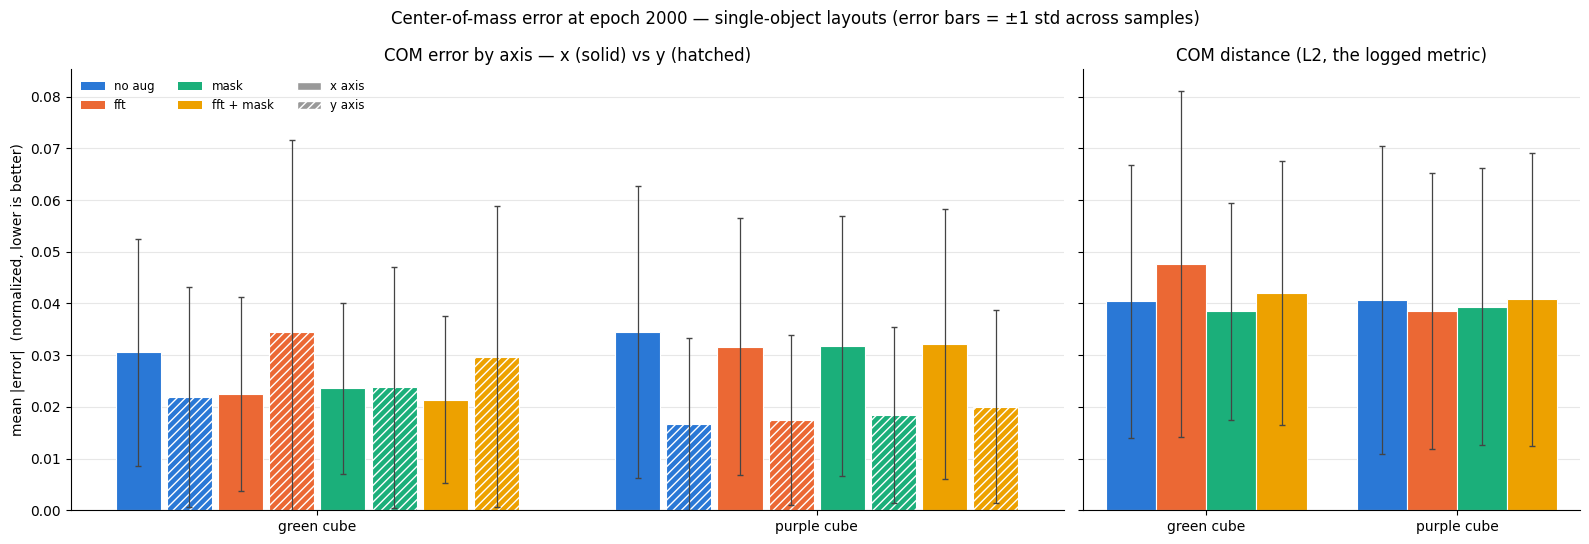

In [10]:
single_layouts = ['green cube', 'purple cube']
HATCH = {'x': '', 'y': '////'}

fig, (ax_xy, ax_l2) = plt.subplots(
    1, 2, figsize=(16, 5.5), sharey=True,  # shared scale: panel heights are comparable
    gridspec_kw={'width_ratios': [2, 1]})

# ── panel 1: x and y adjacent, grouped by layout then by run ──────────────────
group_w = 0.82                       # width of one layout group
run_w = group_w / len(runs)          # width of one run's pair of bars
bar_w = run_w / 2 * 0.88             # single bar, with a small gap between x and y

for li, layout in enumerate(single_layouts):
    for ri, run in enumerate(runs):
        run_centre = li - group_w / 2 + run_w * (ri + 0.5)
        for ai, axis in enumerate(['x', 'y']):
            pos = run_centre + (ai - 0.5) * (run_w / 2)
            v = com[run][layout]
            ax_xy.bar(pos, v[axis], bar_w, color=COLORS[run], hatch=HATCH[axis],
                      edgecolor='white', linewidth=0.8,
                      yerr=v[f'{axis}_std'], capsize=2,
                      error_kw=dict(lw=0.9, ecolor='#444'))

ax_xy.set_xticks(range(len(single_layouts)), single_layouts)
ax_xy.set_title('COM error by axis — x (solid) vs y (hatched)')
ax_xy.set_ylabel('mean |error|  (normalized, lower is better)')

# legend: hue = run, hatch = axis, kept as two separate keys
from matplotlib.patches import Patch
hue_keys = [Patch(facecolor=COLORS[r], label=r) for r in runs]
tex_keys = [Patch(facecolor='#999', hatch=HATCH[a], edgecolor='white', label=f'{a} axis')
            for a in ['x', 'y']]
ax_xy.legend(handles=hue_keys + tex_keys, ncols=3, frameon=False, fontsize=8.5,
             loc='upper left')

# ── panel 2: the logged L2 metric ─────────────────────────────────────────────
xs = np.arange(len(single_layouts))
width = 0.8 / len(runs)
for ri, run in enumerate(runs):
    offset = (ri - (len(runs) - 1) / 2) * width
    means = [com[run][l]['com_distance'] for l in single_layouts]
    errs = [com[run][l]['com_distance_std'] for l in single_layouts]
    ax_l2.bar(xs + offset, means, width, color=COLORS[run], label=run,
              edgecolor='white', linewidth=0.8,
              yerr=errs, capsize=2, error_kw=dict(lw=0.9, ecolor='#444'))
ax_l2.set_xticks(xs, single_layouts)
ax_l2.set_title('COM distance (L2, the logged metric)')

for ax in (ax_xy, ax_l2):
    ax.grid(axis='y', alpha=0.3)
    ax.set_axisbelow(True)
    ax.set_ylim(0, None)
    for spine in ('top', 'right'):
        ax.spines[spine].set_visible(False)

fig.suptitle(f'Center-of-mass error at epoch {TARGET_EPOCH} — single-object layouts '
             f'(error bars = ±1 std across samples)')
plt.tight_layout()
plt.show()

### 6c. Is the error already normalized? Percent-of-extent vs. raw pixels

Worth being explicit about, because it changes how the previous plot should be read:
**`center_of_mass(..., normalize=True)` already divides by the grid extent.**

```python
if normalize: row, col = row / (H - 1), col / (W - 1)
```

So the numbers in 6b are *not* raw pixel offsets — they are already fractions of height (for y)
and of width (for x). Multiplied by 100 they are the "percent of the time we are off given the
relative size" quantity directly.

The catch is that the mask is **20 × 40** — twice as wide as it is tall — so x and y are divided
by *different* denominators (`W-1 = 39` vs `H-1 = 19`). Two legitimate views of the same numbers:

| view | denominator | answers |
|---|---|---|
| **% of extent** | `W-1` for x, `H-1` for y | how far off relative to how much room there is on that axis |
| **pixels** | none (multiply the fraction back out) | how far off in absolute mask cells |

These disagree, and the disagreement is the point. A fixed pixel error on the wide axis is a
*smaller* fraction of the width than the same pixel error on the short axis is of the height, so
normalizing compresses x relative to y by exactly 39/19 ≈ 2.05×. Both panels are plotted below so
the comparison is explicit rather than implied.

mask grid: 20 x 40  ->  y divided by 19, x divided by 39  (ratio 2.05x)


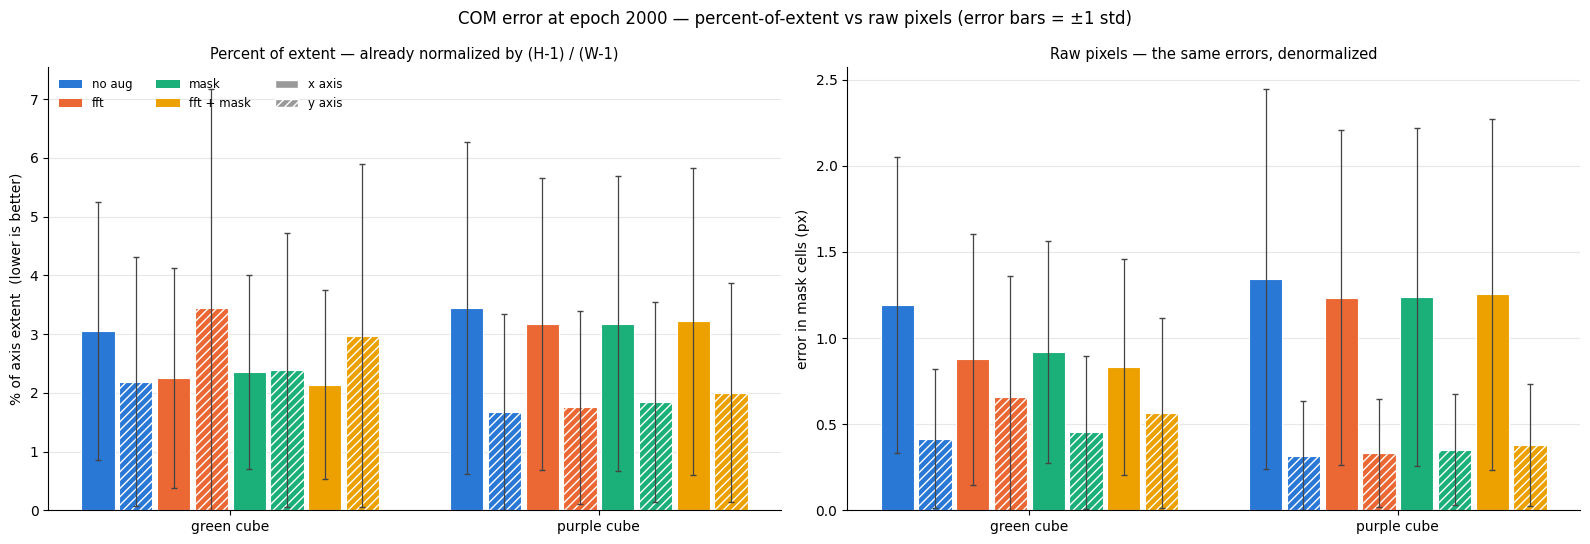

In [11]:
OUT_H, OUT_W = DATA_INFO['out_h'], DATA_INFO['out_w']
DENOM = {'x': OUT_W - 1, 'y': OUT_H - 1}   # what center_of_mass(normalize=True) divided by
print(f'mask grid: {OUT_H} x {OUT_W}  ->  y divided by {DENOM["y"]}, x divided by {DENOM["x"]}'
      f'  (ratio {DENOM["x"] / DENOM["y"]:.2f}x)')

fig, (ax_pct, ax_px) = plt.subplots(1, 2, figsize=(16, 5.5))

panels = [
    (ax_pct, 'pct', '% of axis extent  (lower is better)',
     'Percent of extent — already normalized by (H-1) / (W-1)'),
    (ax_px,  'px',  'error in mask cells (px)',
     'Raw pixels — the same errors, denormalized'),
]

group_w = 0.82
run_w = group_w / len(runs)
bar_w = run_w / 2 * 0.88

for ax, kind, ylabel, title in panels:
    for li, layout in enumerate(single_layouts):
        for ri, run in enumerate(runs):
            run_centre = li - group_w / 2 + run_w * (ri + 0.5)
            for ai, axis in enumerate(['x', 'y']):
                v = com[run][layout]
                # v[axis] is the normalized fraction; scale to percent or back to pixels
                scale = 100.0 if kind == 'pct' else DENOM[axis]
                ax.bar(run_centre + (ai - 0.5) * (run_w / 2), v[axis] * scale, bar_w,
                       color=COLORS[run], hatch=HATCH[axis],
                       edgecolor='white', linewidth=0.8,
                       yerr=v[f'{axis}_std'] * scale, capsize=2,
                       error_kw=dict(lw=0.9, ecolor='#444'))
    ax.set_xticks(range(len(single_layouts)), single_layouts)
    ax.set_title(title, fontsize=10.5)
    ax.set_ylabel(ylabel)
    ax.grid(axis='y', alpha=0.3)
    ax.set_axisbelow(True)
    ax.set_ylim(0, None)
    for spine in ('top', 'right'):
        ax.spines[spine].set_visible(False)

ax_pct.legend(handles=hue_keys + tex_keys, ncols=3, frameon=False, fontsize=8.5, loc='upper left')

fig.suptitle(f'COM error at epoch {TARGET_EPOCH} — percent-of-extent vs raw pixels '
             f'(error bars = ±1 std)')
plt.tight_layout()
plt.show()

In [12]:
# the same thing as a table, since the two views invert the x-vs-y story
rows = []
for run in runs:
    for layout in single_layouts:
        v = com[run][layout]
        rows.append(dict(run=run, layout=layout,
                         x_pct=v['x'] * 100, y_pct=v['y'] * 100,
                         x_px=v['x'] * DENOM['x'], y_px=v['y'] * DENOM['y']))
extent_df = pd.DataFrame(rows).set_index(['run', 'layout'])
extent_df['x/y (pct)'] = extent_df.x_pct / extent_df.y_pct
extent_df['x/y (px)'] = extent_df.x_px / extent_df.y_px
extent_df.round(3)

x_pct  y_pct   x_px   y_px  x/y (pct)  x/y (px)
run        layout                                                      
no aug     green cube   3.057  2.192  1.192  0.416      1.395     2.863
           purple cube  3.445  1.668  1.344  0.317      2.066     4.241
fft        green cube   2.248  3.451  0.877  0.656      0.651     1.337
           purple cube  3.168  1.751  1.235  0.333      1.809     3.713
mask       green cube   2.358  2.383  0.919  0.453      0.989     2.030
           purple cube  3.179  1.844  1.240  0.350      1.724     3.538
fft + mask green cube   2.140  2.974  0.834  0.565      0.719     1.477
           purple cube  3.217  2.001  1.254  0.380      1.607     3.299

## 7. soft-IoU with spread

The section-3 bar plot shows only means, which makes small gaps look more meaningful than they
are. The logs can't do better — `SoftIoU` accumulates a running `total`/`count` and logs only
`total / count`, so no spread survives. But the section-6 eval pass has the **per-sample** IoU
vector for each layout, so std is available there.

Two different quantities, plotted side by side — they answer different questions:

- **std** — spread across samples: how much IoU varies from one sample to the next. Large by
  nature; it does *not* shrink with more data and is not a claim about the mean's precision.
- **SEM** (`std / √n`) — uncertainty of the mean itself. This is the one to read when asking
  whether two runs actually differ.

**Eval layouts only — `train` is deliberately excluded here.** The sanity check in 6a shows the
recomputed `train` IoU failing to reproduce the log for two of the runs, for a real reason rather
than a bug worth patching around:

- For the **`mask` runs**, mask augmentation perturbs `mask_true`, the *target*. The logged
  train-eval pass scores against the augmented target; this notebook's eval dataset sets
  `augment_mask=0` and so scores against the clean one. Those are different quantities (~5e-2
  apart), and neither is wrong — they just aren't the same measurement. The `fft` run reproduces
  exactly, since fft augmentation only touches the input.
- For **`no aug`** a smaller ~2e-2 residual remains, consistent with train-eval being taken over a
  different pass than the per-batch training metric.

Every **eval** layout reproduces the log to ~1e-5 in 6a, so the spread shown below is trustworthy;
train is the only untrustworthy row, and it is the least interesting one for this question.

The eval sets are small (green cube n=16, purple cube n=64, green+purple n=56), so SEM is wide.

In [13]:
iou_stats = pd.DataFrame(
    {(run, layout): dict(mean=v['soft_iou'], std=v['soft_iou_std'], sem=v['soft_iou_sem'], n=v['n'])
     for run, layouts in com.items() for layout, v in layouts.items()}).T
iou_stats.index.names = ['run', 'layout']
iou_stats['n'] = iou_stats['n'].astype(int)
iou_stats

mean       std       sem    n
run        layout                                               
no aug     train               0.915493  0.159276  0.005522  832
           green cube          0.649250  0.139975  0.034994   16
           purple cube         0.579549  0.197888  0.024736   64
           purple green cubes  0.387321  0.198539  0.026531   56
fft        train               0.898666  0.157744  0.005469  832
           green cube          0.629337  0.126406  0.031601   16
           purple cube         0.607108  0.171941  0.021493   64
           purple green cubes  0.393343  0.194280  0.025962   56
mask       train               0.786121  0.138400  0.004798  832
           green cube          0.631879  0.090969  0.022742   16
           purple cube         0.568472  0.146532  0.018317   64
           purple green cubes  0.385816  0.179622  0.024003   56
fft + mask train               0.787667  0.137640  0.004772  832
           green cube          0.623986  0.095699  0.023925   16
           purple cube         0.561501  0.152191  0.019024   64
           purple green cubes  0.407140  0.168721  0.022546   56

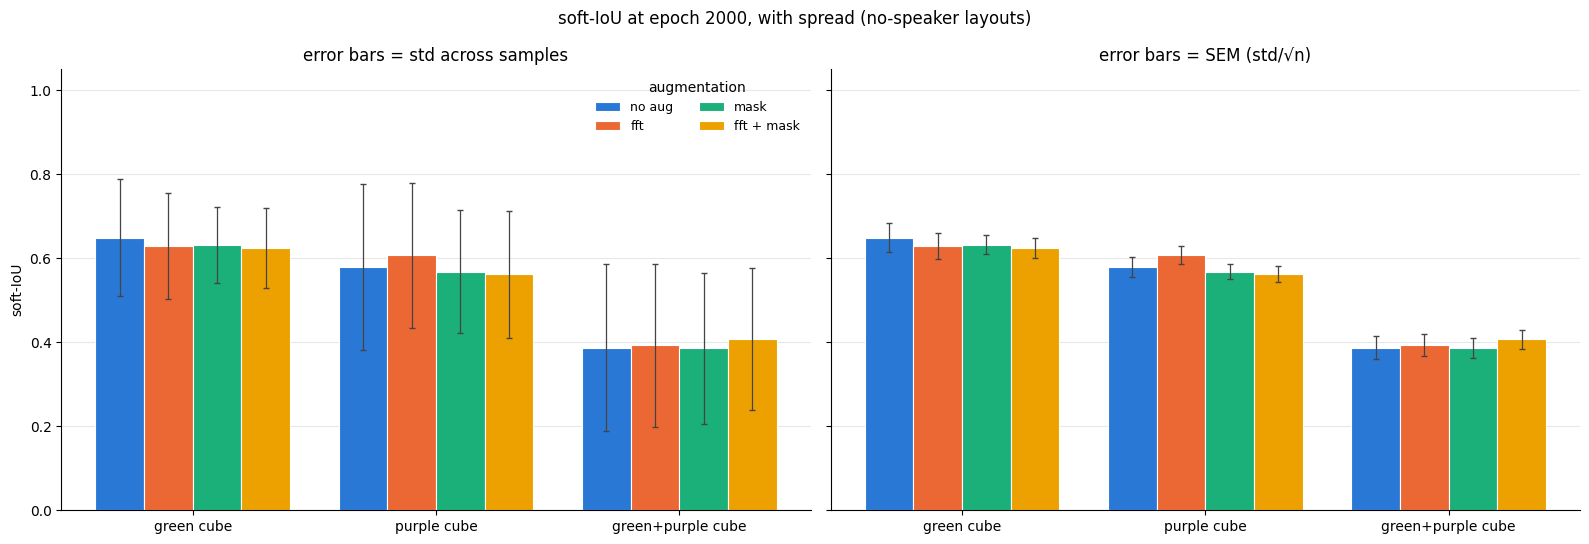

In [14]:
# train excluded: it does not reproduce the log for the mask runs (see above)
plot_layouts = ['green cube', 'purple cube', 'purple green cubes']

fig, axes = plt.subplots(1, 2, figsize=(16, 5.5), sharey=True)

for ax, err_kind in zip(axes, ['std', 'sem']):
    xs = np.arange(len(plot_layouts))
    width = 0.8 / len(runs)
    for i, run in enumerate(runs):
        means = [com[run][l]['soft_iou'] for l in plot_layouts]
        errs = [com[run][l][f'soft_iou_{err_kind}'] for l in plot_layouts]
        offset = (i - (len(runs) - 1) / 2) * width
        ax.bar(xs + offset, means, width, label=run, color=COLORS[run],
               edgecolor='white', linewidth=0.8,
               yerr=errs, capsize=2, error_kw=dict(lw=0.9, ecolor='#444'))
    ax.set_xticks(xs, [l.replace('purple green cubes', 'green+purple cube') for l in plot_layouts])
    ax.set_title(f'error bars = {"std across samples" if err_kind == "std" else "SEM (std/√n)"}')
    ax.grid(axis='y', alpha=0.3)
    ax.set_axisbelow(True)
    for spine in ('top', 'right'):
        ax.spines[spine].set_visible(False)

axes[0].set_ylabel('soft-IoU')
axes[0].set_ylim(0, 1.05)
axes[0].legend(title='augmentation', ncols=2, frameon=False, fontsize=9)

fig.suptitle(f'soft-IoU at epoch {TARGET_EPOCH}, with spread (no-speaker layouts)')
plt.tight_layout()
plt.show()